# TP — Réseaux antagonistes génératifs (GAN) avec PyTorch




Les cellules marquées **`# TODO`** sont à compléter. 

> **Conseil :** exécutez ce notebook dans **Google Colab** (Fichier › Importer le notebook, puis Exécution › Modifier le type d'exécution › GPU). Il fonctionne aussi sur CPU, en un peu plus de temps.

## Rappel : le principe d'un GAN

- Le **générateur** $G$ reçoit un bruit aléatoire $z \sim \mathcal{N}(0, I)$ et produit un faux échantillon $G(z)$.
- Le **discriminateur** $D$ reçoit un échantillon et renvoie la probabilité $D(x)$ qu'il soit **réel**.

Les deux réseaux jouent un jeu à somme nulle :

$$\min_G \max_D \; \mathbb{E}_{x \sim p_{\text{data}}}\big[\log D(x)\big] + \mathbb{E}_{z \sim p_z}\big[\log\big(1 - D(G(z))\big)\big]$$

En pratique, on alterne à chaque itération :
1. **Étape D** : on entraîne $D$ à répondre 1 sur les vrais échantillons et 0 sur les faux.
2. **Étape G** : on entraîne $G$ à ce que $D$ réponde 1 sur ses faux échantillons.

Les deux étapes s'écrivent avec la **binary cross-entropy** : $\text{BCE}(p, y) = -\big[y \log p + (1-y)\log(1-p)\big]$.

---
# Partie 0 — Mise en place
Sur Colab, tout est déjà installé. En local : `pip install torch torchvision matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device :", device)

PyTorch 2.14.1+cpu | device : cpu


---
# Partie 1 — Échauffement : un GAN en 1 dimension

On veut que $G$ apprenne à imiter une loi très simple : une **gaussienne de moyenne 4 et d'écart-type 1,25**.
$G$ ne voit jamais les vraies données ; il n'apprend qu'à travers le jugement de $D$.

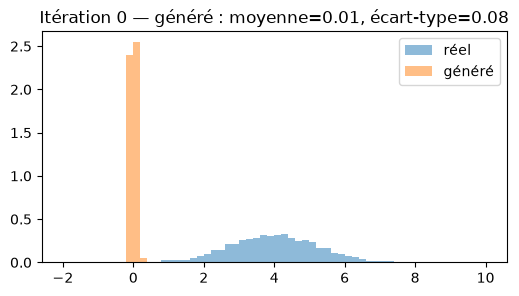

In [2]:
REAL_MEAN, REAL_STD = 4.0, 1.25
NOISE_DIM_1D = 8

def sample_real(n):
    # Vrais échantillons : N(4, 1.25²), forme (n, 1)
    return torch.randn(n, 1) * REAL_STD + REAL_MEAN

def sample_noise_1d(n):
    # Bruit d'entrée du générateur, forme (n, NOISE_DIM_1D)
    return torch.randn(n, NOISE_DIM_1D)

G1 = nn.Sequential(
    nn.Linear(NOISE_DIM_1D, 32), nn.ReLU(),
    nn.Linear(32, 32), nn.ReLU(),
    nn.Linear(32, 1),
)
D1 = nn.Sequential(
    nn.Linear(1, 32), nn.LeakyReLU(0.2),
    nn.Linear(32, 32), nn.LeakyReLU(0.2),
    nn.Linear(32, 1),            # pas de sigmoïde : on renvoie un « logit »
)

criterion = nn.BCEWithLogitsLoss()   # = sigmoïde + BCE, plus stable numériquement
opt_G1 = torch.optim.Adam(G1.parameters(), lr=1e-3, betas=(0.5, 0.999))
opt_D1 = torch.optim.Adam(D1.parameters(), lr=1e-3, betas=(0.5, 0.999))

def show_1d(step):
    with torch.no_grad():
        fake = G1(sample_noise_1d(5000)).squeeze().numpy()
    real = sample_real(5000).squeeze().numpy()
    plt.figure(figsize=(6, 3))
    plt.hist(real, bins=60, range=(-2, 10), alpha=0.5, density=True, label="réel")
    plt.hist(fake, bins=60, range=(-2, 10), alpha=0.5, density=True, label="généré")
    plt.title(f"Itération {step} — généré : moyenne={fake.mean():.2f}, écart-type={fake.std():.2f}")
    plt.legend(); plt.show()

show_1d(0)   # avant entraînement

### À faire : l'étape d'entraînement
Complétez `train_step_1d`. Elle doit :
1. **Étape D** : calculer la perte de $D$ sur un lot de vrais échantillons (étiquette 1) et un lot de faux (étiquette 0), puis faire un pas d'optimisation de $D$.
2. **Étape G** : générer un nouveau lot de faux, calculer la perte de $G$ **en utilisant l'étiquette 1**, puis faire un pas d'optimisation de $G$.

Rappel PyTorch : `optimiseur.zero_grad()`, `perte.backward()`, `optimiseur.step()`.